# Noise Evaluation on all 3 Ensemble Models

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from catboost import CatBoostClassifier
from sklearn.preprocessing import StandardScaler
import joblib
import sys
sys.path.append("..")
from utils.metrics import evaluate, compare_splits

SEED = 67
np.random.seed(SEED)
torch.manual_seed(SEED)

In [2]:
NOISE_FEAT_PATH = "../features/ensemble_noise"
DENSE_NOISE_PATH = "../features/dense_noise"
MODEL_PATH = "../models"

VARIANTS = ['salt_pepper_0.03', 'salt_pepper_0.05', 'salt_pepper_0.07', 'gaussian', 'masking']
NUM_CLASSES = 38

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", DEVICE)

Device : cuda


# Loading Ensemble Models


In [3]:
DIMS = [32, 576, 1024, 768]
BLOCK_NAMES = ["GLCM", "MobileNetV3", "GoogLeNet", "ConvNeXtSmall"]
D_MODEL = 256
N_HEADS = 8
N_LAYERS = 2
DROPOUT = 0.1
BATCH_SIZE = 64

class FusionTransformer(nn.Module):

    def __init__(self, dims, d_model, nhead, num_layers, num_classes, dropout=0.1):
        super().__init__()
        self.projectors = nn.ModuleList([nn.Sequential(nn.Linear(d, d_model), nn.LayerNorm(d_model), nn.GELU())for d in dims])
        self.pos_emb = nn.Parameter(torch.randn(1, len(dims), d_model) * 0.02)
        enc_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,dim_feedforward=d_model * 4,dropout=dropout, batch_first=True, activation="gelu")
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.head = nn.Sequential(nn.LayerNorm(d_model), nn.Dropout(dropout), nn.Linear(d_model, num_classes))

    def forward(self, *feature_groups):
        tokens = torch.stack([p(f) for p, f in zip(self.projectors, feature_groups)], dim=1)
        return self.head(self.transformer(tokens + self.pos_emb).mean(dim=1))

In [4]:
cb_v1 = CatBoostClassifier()
cb_v1.load_model(os.path.join(MODEL_PATH, "catboost_ensemble.cbm"))
scaler_v1 = joblib.load(os.path.join(MODEL_PATH, "ensemble_scaler.pkl"))
print("CatBoost v1 loaded")


CatBoost v1 loaded


In [5]:
cb_v2 = CatBoostClassifier()
cb_v2.load_model(os.path.join(MODEL_PATH, "catboost_ensemble_v2.cbm"))
scaler_v2 = joblib.load(os.path.join(MODEL_PATH, "ensemble_scaler_v2.pkl"))
print("CatBoost v2 loaded")

CatBoost v2 loaded


In [6]:
tf_model = FusionTransformer(DIMS, D_MODEL, N_HEADS, N_LAYERS, NUM_CLASSES, DROPOUT).to(DEVICE)
best_state = torch.load(os.path.join(MODEL_PATH, "transformer_ensemble.pt"), map_location=DEVICE)
tf_model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
scaler_tf = joblib.load(os.path.join(MODEL_PATH, "ensemble_scaler_tf.pkl"))
tf_model.eval()
print("Transformer loaded")

Transformer loaded


In [7]:
def predict_catboost(model, X):
    pred = model.predict(X).flatten().astype(int)
    proba = model.predict_proba(X)
    return pred, proba


def make_loader(X, y):
    splits = torch.split(torch.tensor(X, dtype=torch.float32), DIMS, dim=1)
    labels = torch.tensor(y, dtype=torch.long)
    return DataLoader(TensorDataset(*splits, labels), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)


def get_preds(loader):
    tf_model.eval()
    all_true, all_pred, all_prob = [], [], []
    with torch.no_grad():
        for *feats, y in loader:
            probs    = torch.softmax(tf_model(*[f.to(DEVICE) for f in feats]), dim=1).cpu().numpy()
            all_true.append(y.numpy())
            all_pred.append(probs.argmax(axis=1))
            all_prob.append(probs)
    return np.concatenate(all_true), np.concatenate(all_pred), np.vstack(all_prob)

# Model Evaluation

  CATBOOST V1 — NOISED TEST  |  salt_pepper_0.03

===== METRICS =====


Metrics,Value
Accuracy,0.939954
Precision,0.945258
Recall,0.939525
F1_Score,0.939471
ROC_AUC,0.999392
Log_loss,0.233319



============================ CONFUSION MATRIX =============================


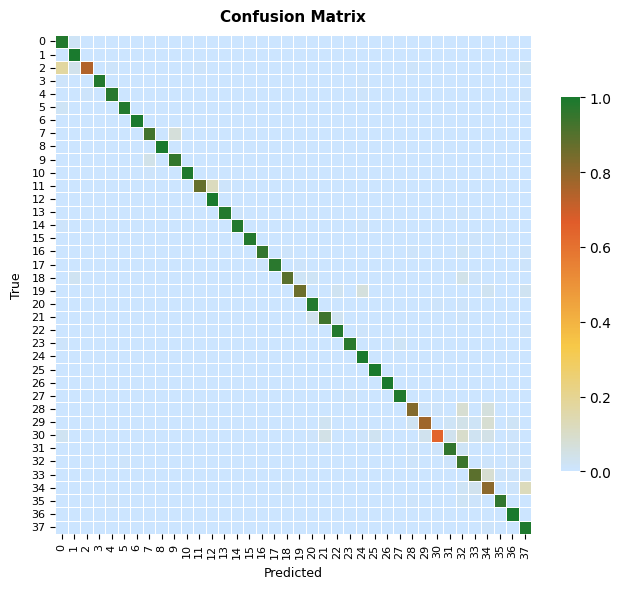


==================================== ROC CURVE ====================================


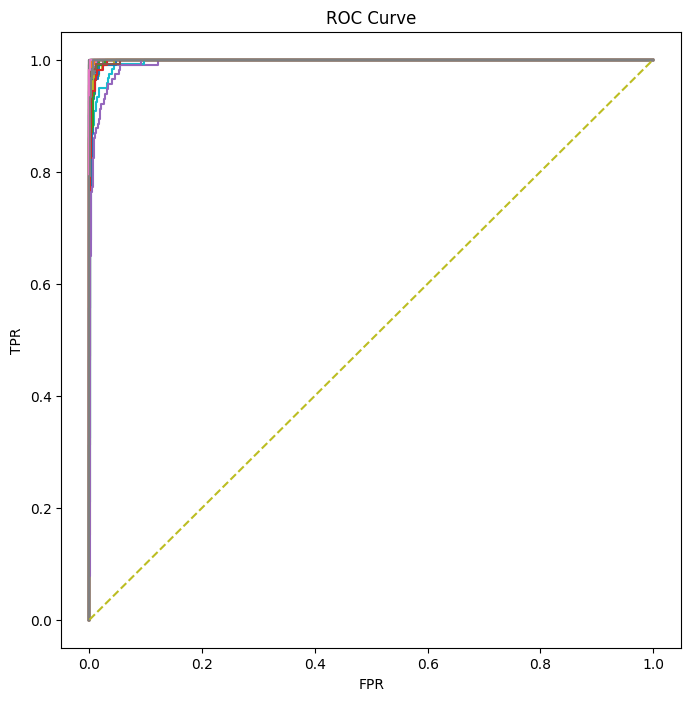


  CATBOOST V1 — NOISED TEST  |  salt_pepper_0.05

===== METRICS =====


Metrics,Value
Accuracy,0.885845
Precision,0.910751
Recall,0.884665
F1_Score,0.885610
ROC_AUC,0.998641
Log_loss,0.398126



============================ CONFUSION MATRIX =============================


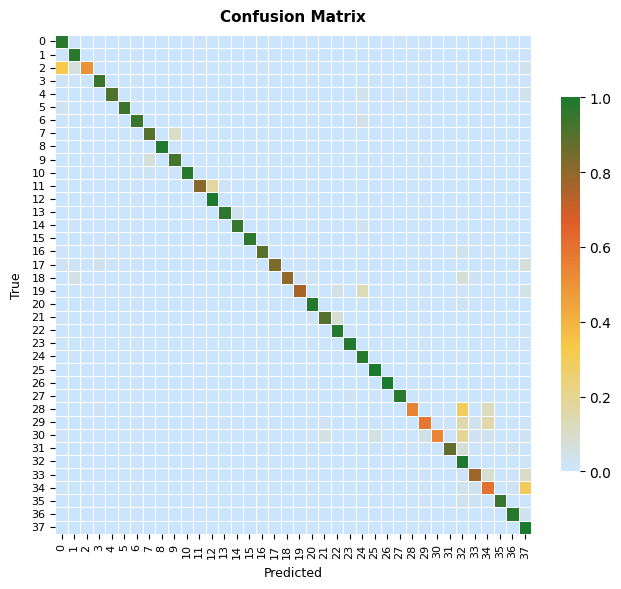


==================================== ROC CURVE ====================================


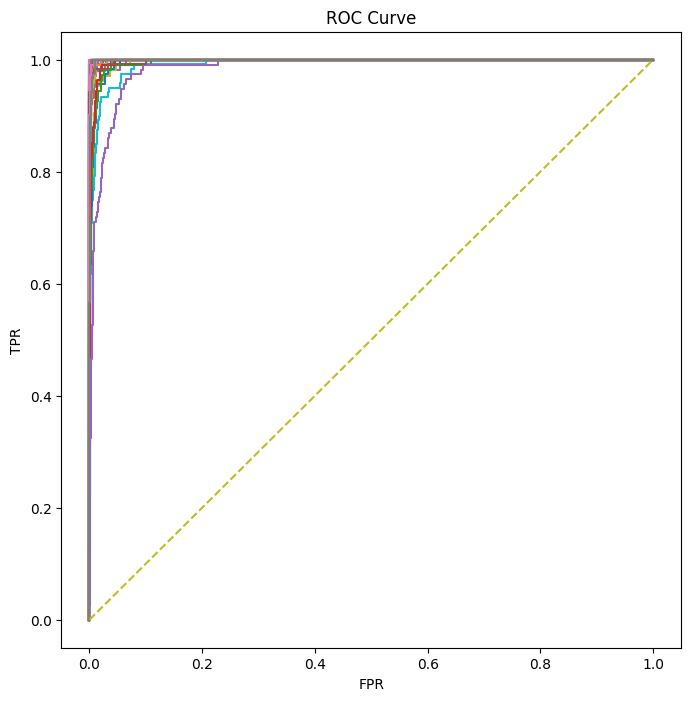


  CATBOOST V1 — NOISED TEST  |  salt_pepper_0.07

===== METRICS =====


Metrics,Value
Accuracy,0.822603
Precision,0.870343
Recall,0.821535
F1_Score,0.819411
ROC_AUC,0.997190
Log_loss,0.595351



============================ CONFUSION MATRIX =============================


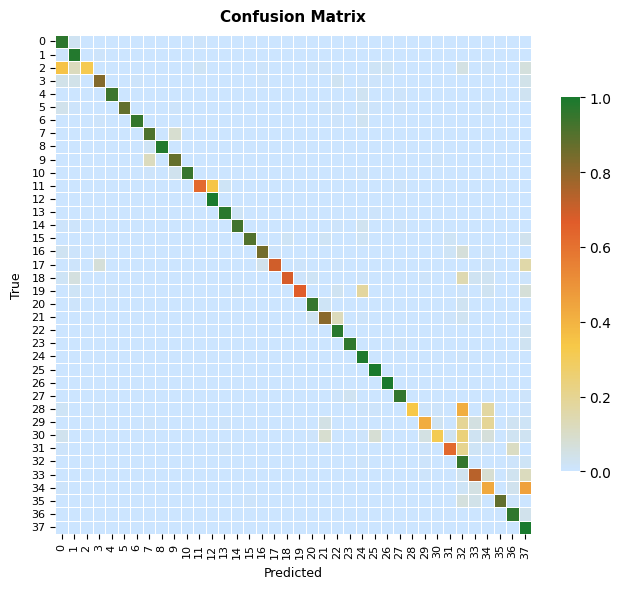


==================================== ROC CURVE ====================================


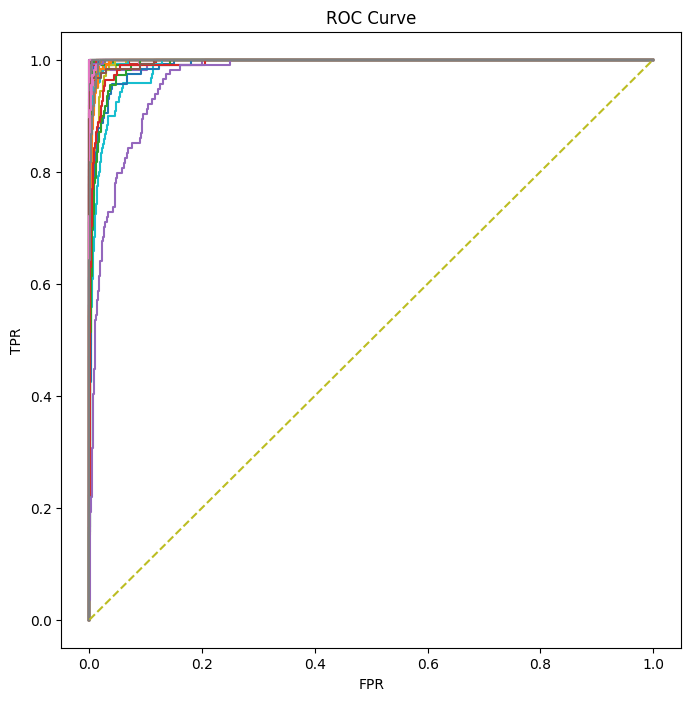


  CATBOOST V1 — NOISED TEST  |  gaussian

===== METRICS =====


Metrics,Value
Accuracy,0.762785
Precision,0.848340
Recall,0.762094
F1_Score,0.760085
ROC_AUC,0.995532
Log_loss,0.772700



============================ CONFUSION MATRIX =============================


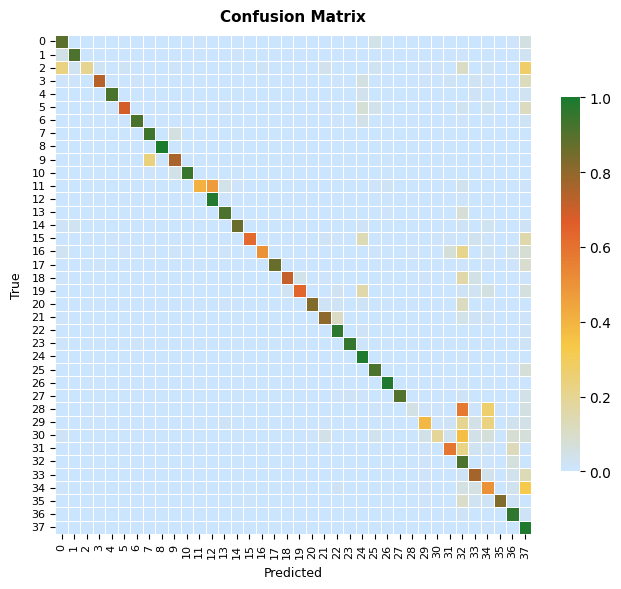


==================================== ROC CURVE ====================================


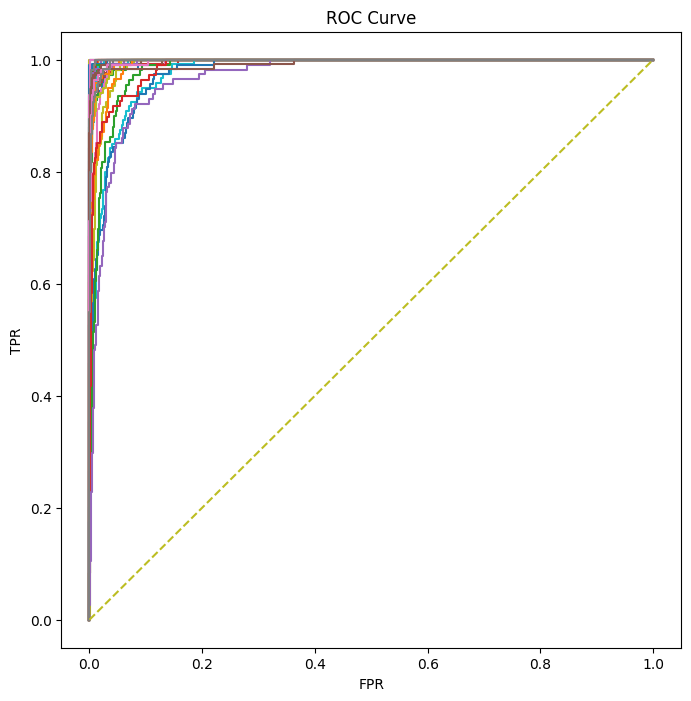


  CATBOOST V1 — NOISED TEST  |  masking

===== METRICS =====


Metrics,Value
Accuracy,0.867123
Precision,0.889429
Recall,0.866960
F1_Score,0.863560
ROC_AUC,0.998711
Log_loss,0.499135



============================ CONFUSION MATRIX =============================


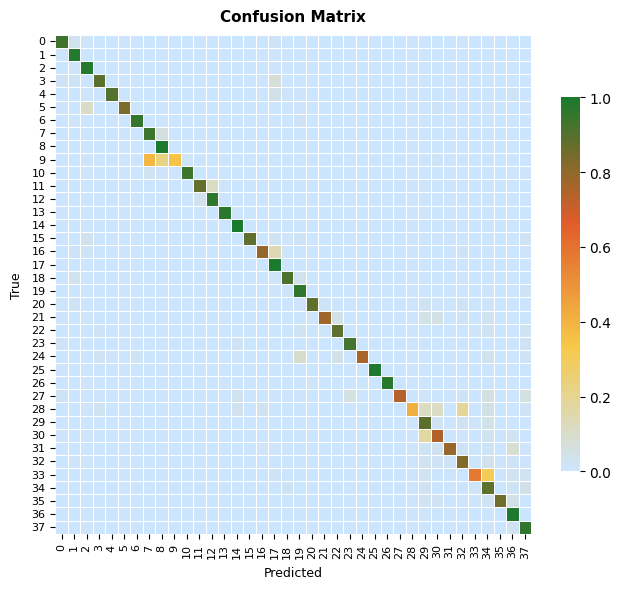


==================================== ROC CURVE ====================================


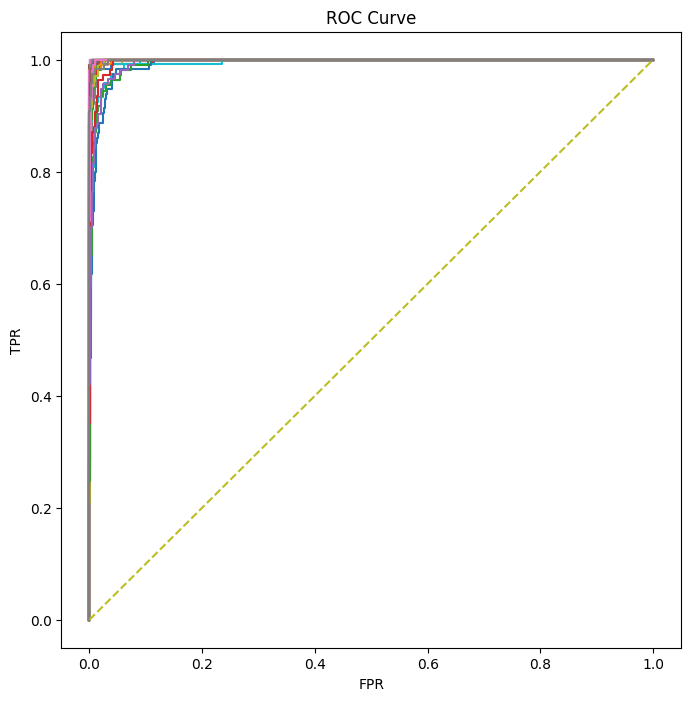

In [8]:
metrics_v1   = {}

for variant in VARIANTS:
    print("=" * 60)
    print(f"  CATBOOST V1 — NOISED TEST  |  {variant}")
    print("=" * 60)

    noise_dir = os.path.join(NOISE_FEAT_PATH, variant)
    X_noise = np.load(os.path.join(noise_dir, "X_noise_test.npy"))
    y_noise = np.load(os.path.join(noise_dir, "y_noise_test.npy"))

    X_v1 = scaler_v1.transform(X_noise)
    pred_v1 = cb_v1.predict(X_v1).flatten().astype(int)
    proba_v1 = cb_v1.predict_proba(X_v1)

    metrics_v1[variant] = evaluate(y_noise, pred_v1, proba_v1)
    print()

  CATBOOST V2 — NOISED TEST  |  salt_pepper_0.03

===== METRICS =====


Metrics,Value
Accuracy,0.958676
Precision,0.960495
Recall,0.958584
F1_Score,0.958213
ROC_AUC,0.999655
Log_loss,0.197015



============================ CONFUSION MATRIX =============================


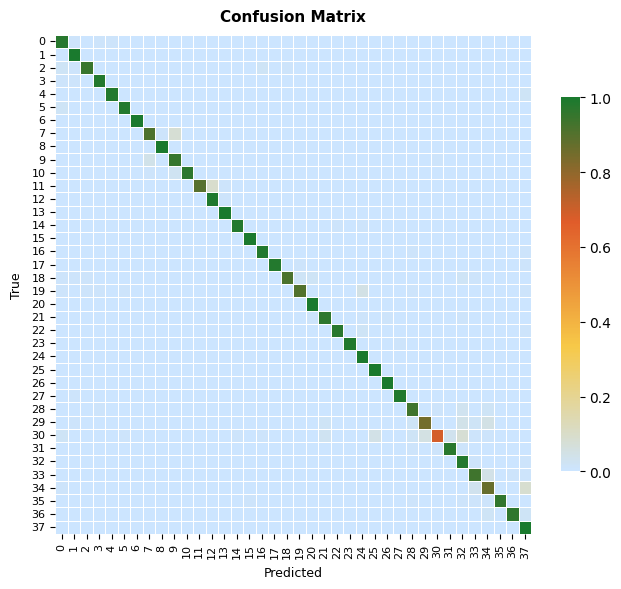


==================================== ROC CURVE ====================================


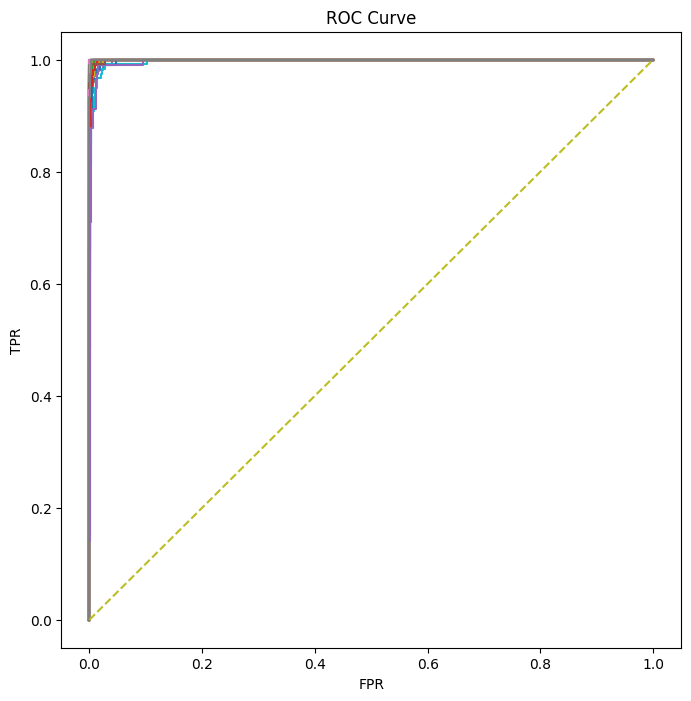


  CATBOOST V2 — NOISED TEST  |  salt_pepper_0.05

===== METRICS =====


Metrics,Value
Accuracy,0.917352
Precision,0.930384
Recall,0.917215
F1_Score,0.917382
ROC_AUC,0.999172
Log_loss,0.322768



============================ CONFUSION MATRIX =============================


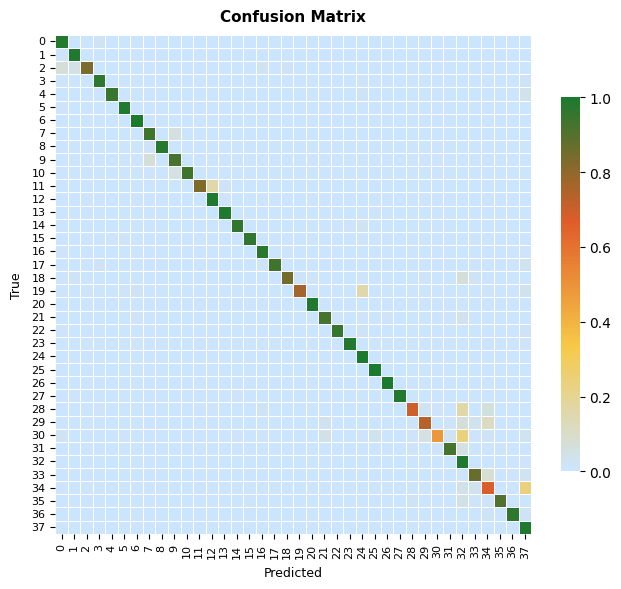


==================================== ROC CURVE ====================================


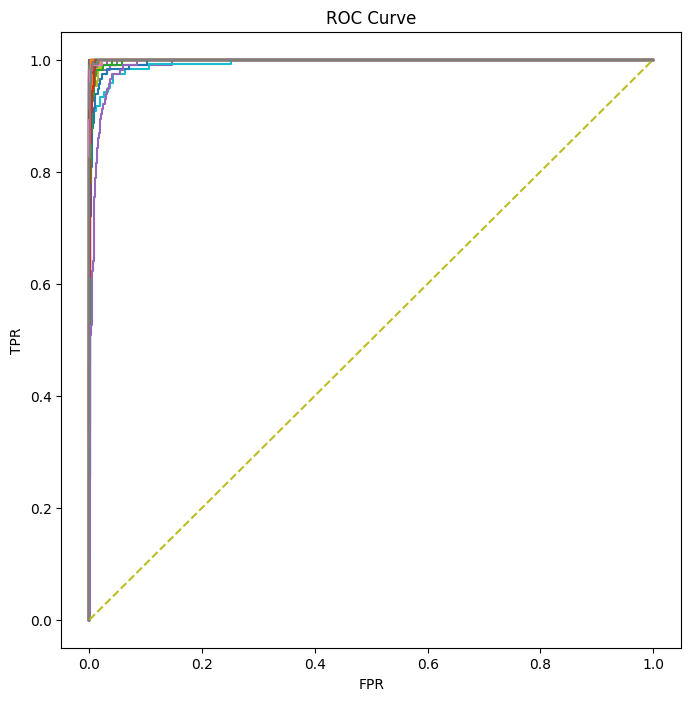


  CATBOOST V2 — NOISED TEST  |  salt_pepper_0.07

===== METRICS =====


Metrics,Value
Accuracy,0.860959
Precision,0.893574
Recall,0.860682
F1_Score,0.860468
ROC_AUC,0.998534
Log_loss,0.483301



============================ CONFUSION MATRIX =============================


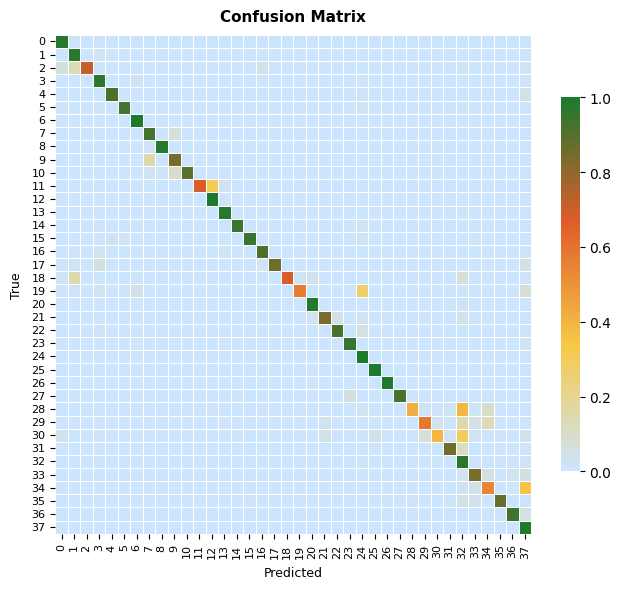


==================================== ROC CURVE ====================================


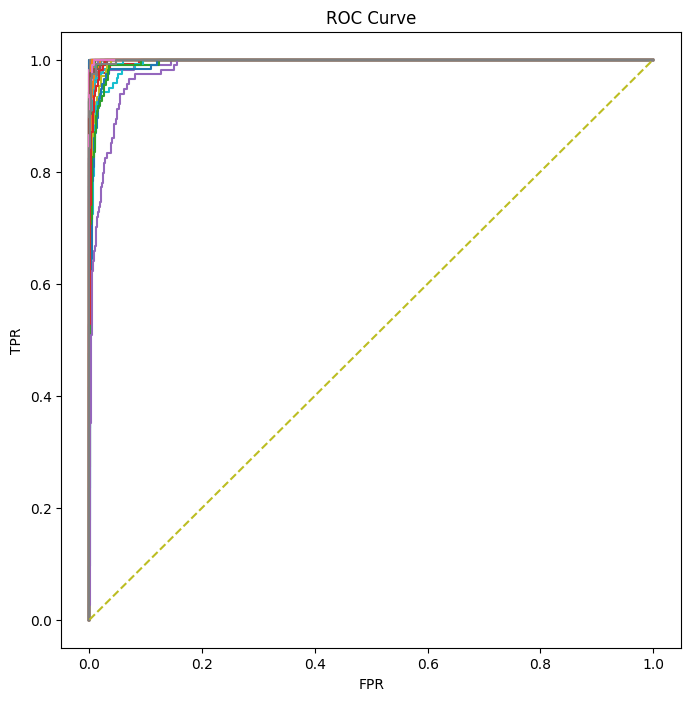


  CATBOOST V2 — NOISED TEST  |  gaussian

===== METRICS =====


Metrics,Value
Accuracy,0.773744
Precision,0.861534
Recall,0.773295
F1_Score,0.774474
ROC_AUC,0.996998
Log_loss,0.766432



============================ CONFUSION MATRIX =============================


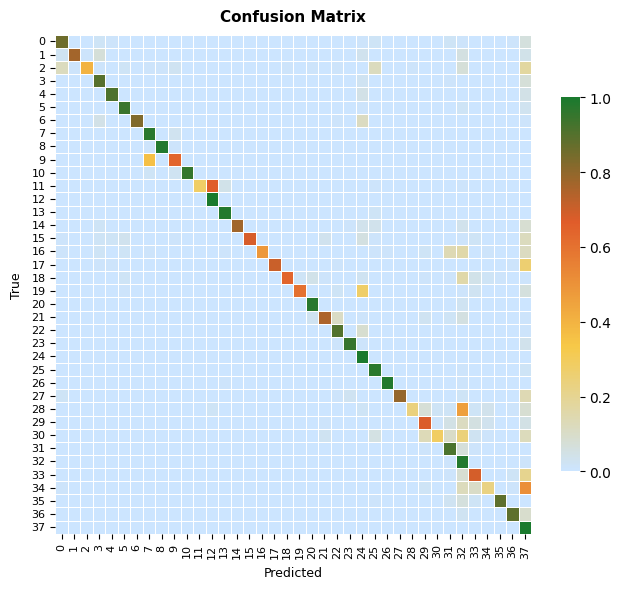


==================================== ROC CURVE ====================================


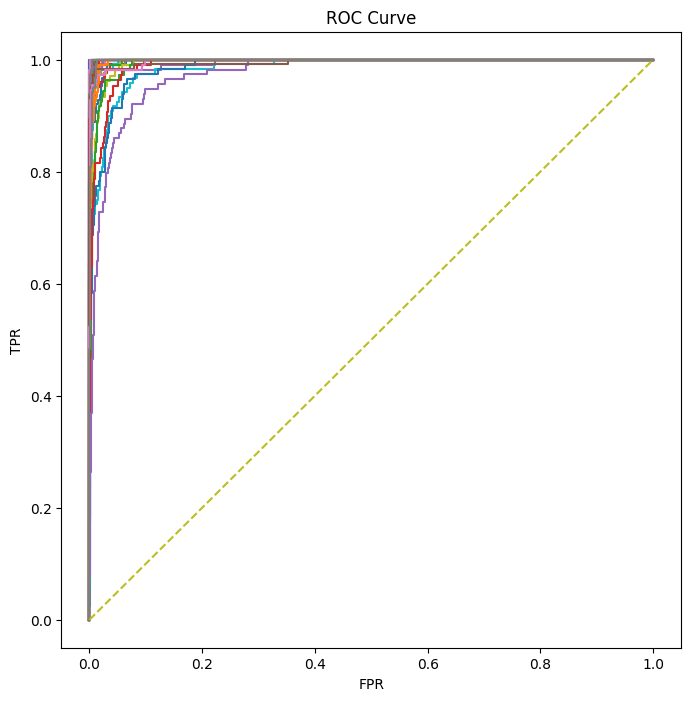


  CATBOOST V2 — NOISED TEST  |  masking

===== METRICS =====


Metrics,Value
Accuracy,0.834475
Precision,0.882373
Recall,0.834391
F1_Score,0.830031
ROC_AUC,0.998628
Log_loss,0.643551



============================ CONFUSION MATRIX =============================


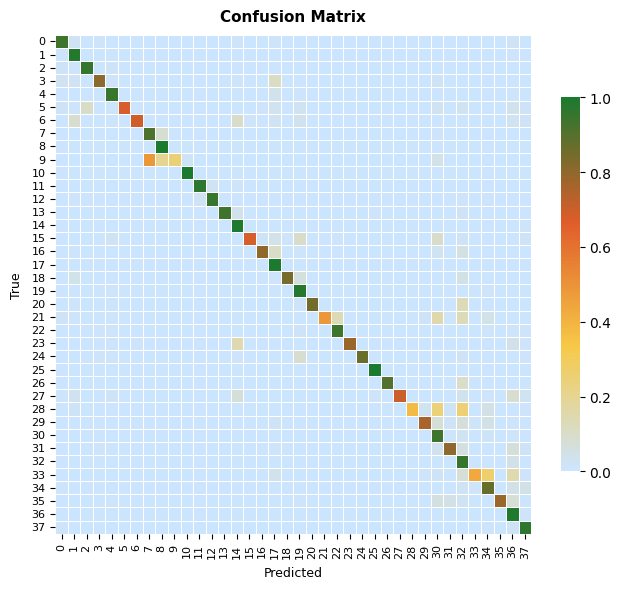


==================================== ROC CURVE ====================================


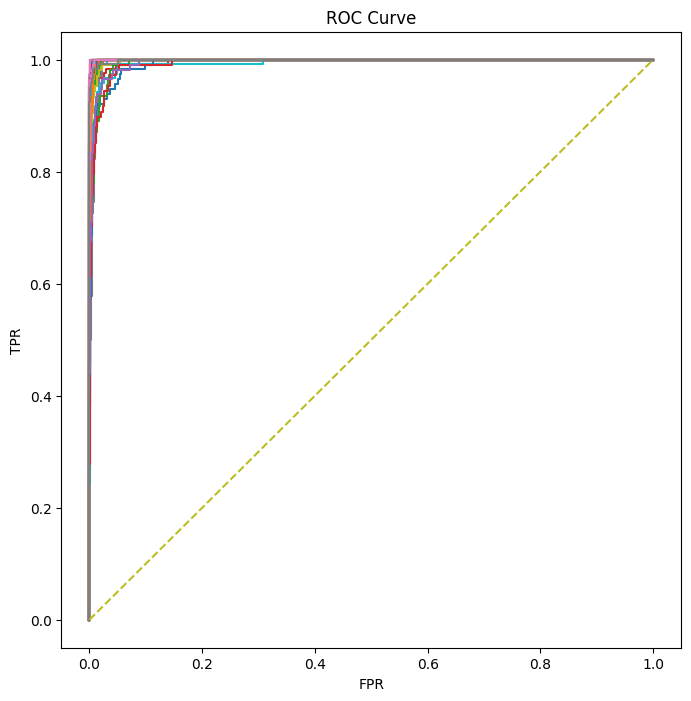

In [9]:
metrics_v2   = {}

for variant in VARIANTS:
    print("=" * 60)
    print(f"  CATBOOST V2 — NOISED TEST  |  {variant}")
    print("=" * 60)

    noise_dir = os.path.join(NOISE_FEAT_PATH, variant)
    dense_dir = os.path.join(DENSE_NOISE_PATH, variant)
    X_noise = np.load(os.path.join(noise_dir, "X_noise_test.npy"))
    y_noise = np.load(os.path.join(noise_dir, "y_noise_test.npy"))
    X_dense = np.load(os.path.join(dense_dir, "X_dense_noise_test.npy"))

    X_v2 = scaler_v2.transform(np.concatenate([X_noise, X_dense], axis=1))
    pred_v2 = cb_v2.predict(X_v2).flatten().astype(int)
    proba_v2 = cb_v2.predict_proba(X_v2)

    metrics_v2[variant] = evaluate(y_noise, pred_v2, proba_v2)
    print()


  TRANSFORMER FUSION — NOISED TEST  |  salt_pepper_0.03

===== METRICS =====


Metrics,Value
Accuracy,0.977626
Precision,0.978811
Recall,0.977663
F1_Score,0.977446
ROC_AUC,0.999910
Log_loss,0.151251



============================ CONFUSION MATRIX =============================


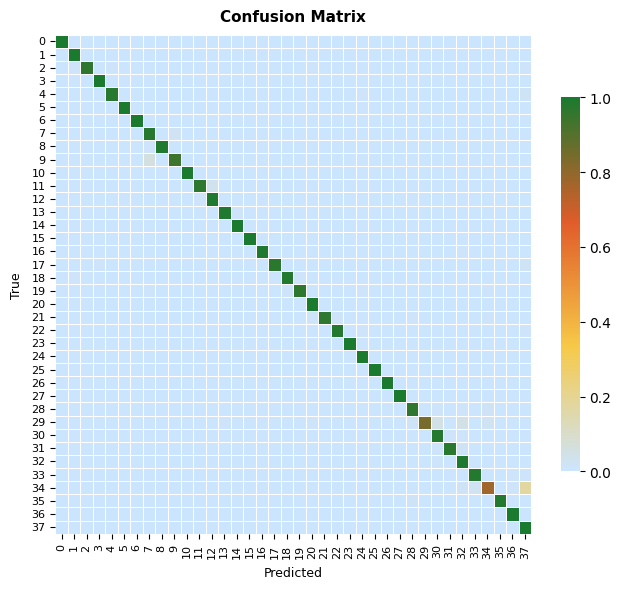


==================================== ROC CURVE ====================================


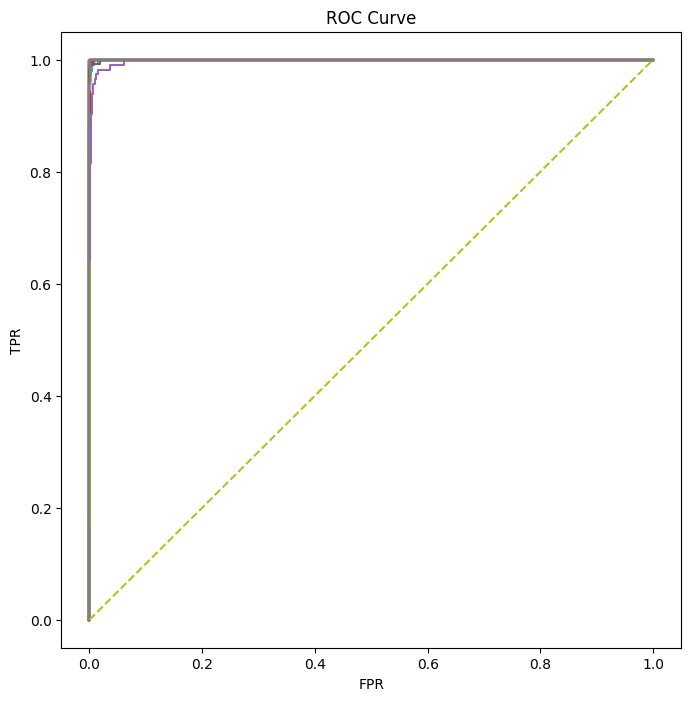


  TRANSFORMER FUSION — NOISED TEST  |  salt_pepper_0.05

===== METRICS =====


Metrics,Value
Accuracy,0.948630
Precision,0.957576
Recall,0.948342
F1_Score,0.949058
ROC_AUC,0.999595
Log_loss,0.291305



============================ CONFUSION MATRIX =============================


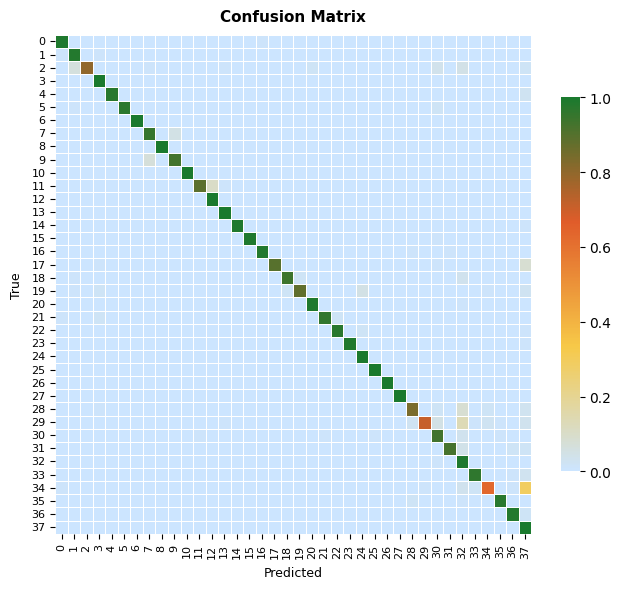


==================================== ROC CURVE ====================================


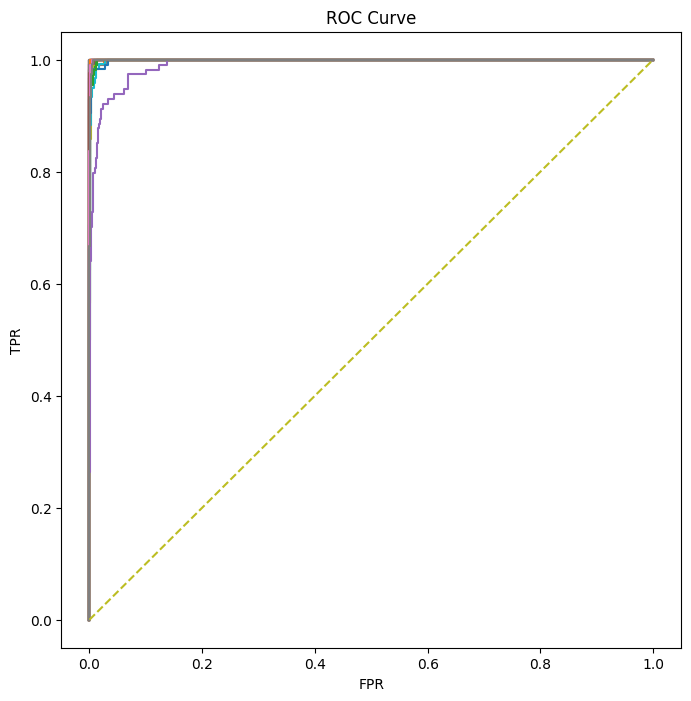


  TRANSFORMER FUSION — NOISED TEST  |  salt_pepper_0.07

===== METRICS =====


Metrics,Value
Accuracy,0.900228
Precision,0.925087
Recall,0.899712
F1_Score,0.901288
ROC_AUC,0.998466
Log_loss,0.489872



============================ CONFUSION MATRIX =============================


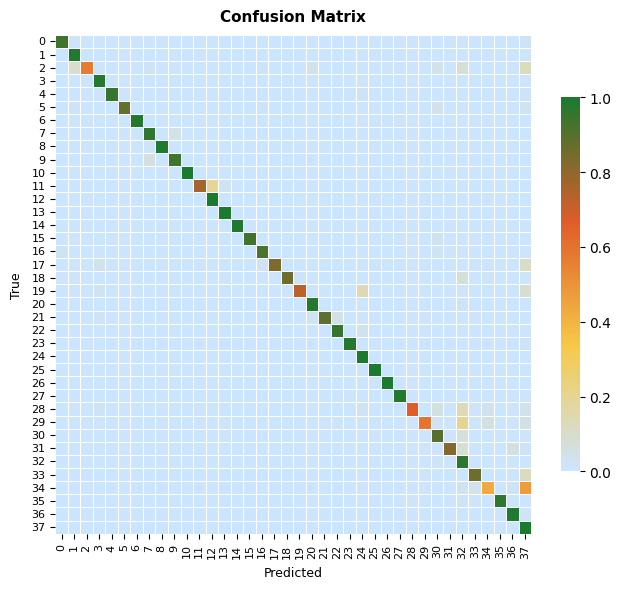


==================================== ROC CURVE ====================================


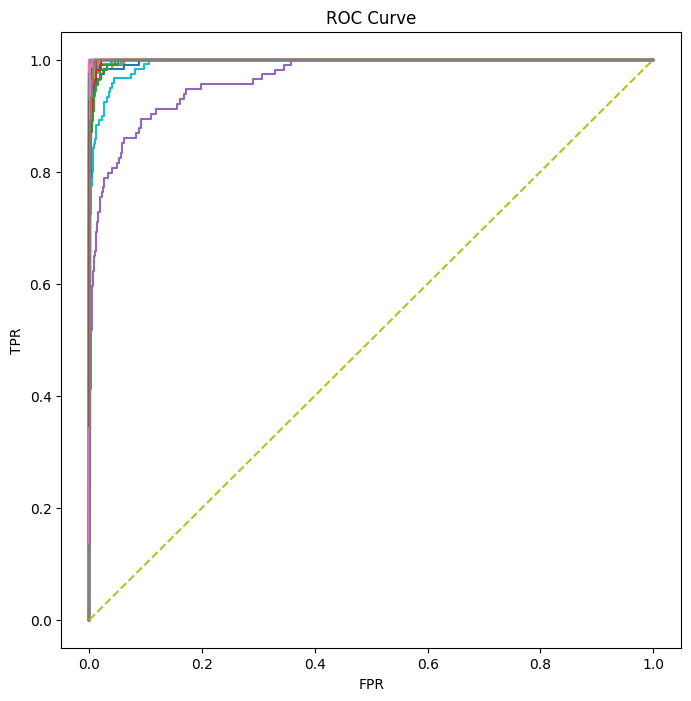


  TRANSFORMER FUSION — NOISED TEST  |  gaussian

===== METRICS =====


Metrics,Value
Accuracy,0.850228
Precision,0.901668
Recall,0.849711
F1_Score,0.853113
ROC_AUC,0.996776
Log_loss,0.633568



============================ CONFUSION MATRIX =============================


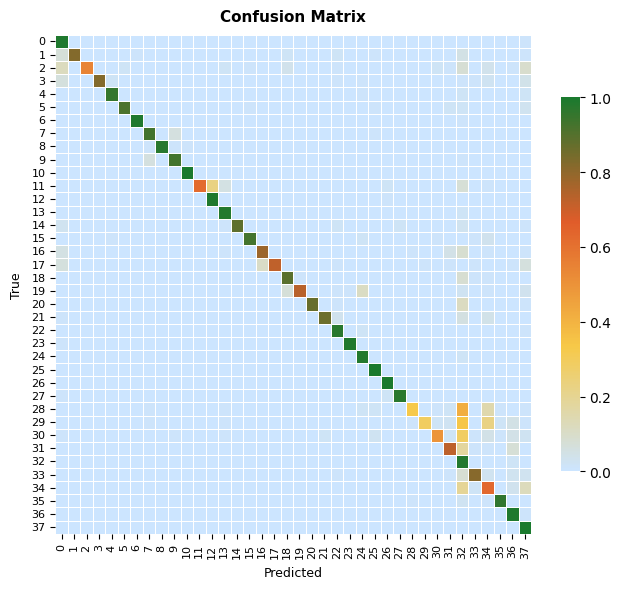


==================================== ROC CURVE ====================================


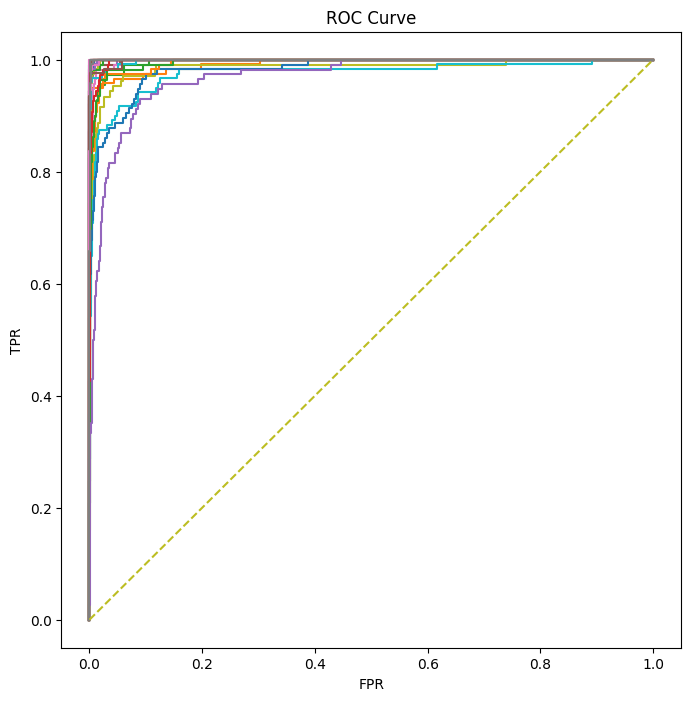


  TRANSFORMER FUSION — NOISED TEST  |  masking

===== METRICS =====


Metrics,Value
Accuracy,0.942009
Precision,0.947707
Recall,0.941871
F1_Score,0.940071
ROC_AUC,0.999106
Log_loss,0.388066



============================ CONFUSION MATRIX =============================


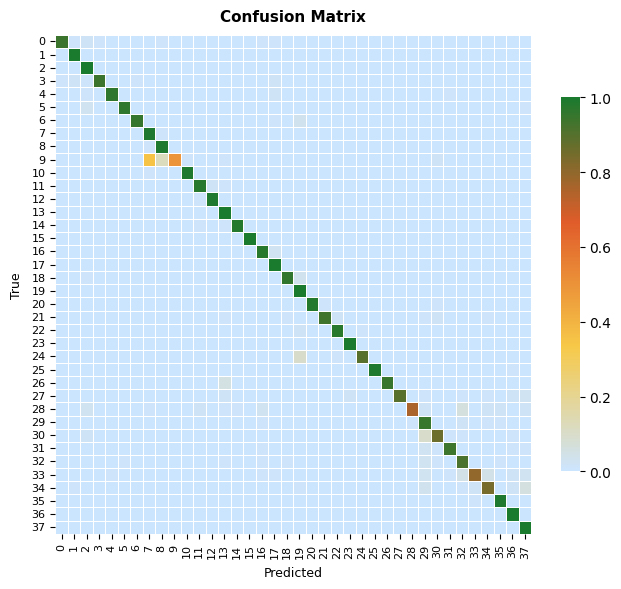


==================================== ROC CURVE ====================================


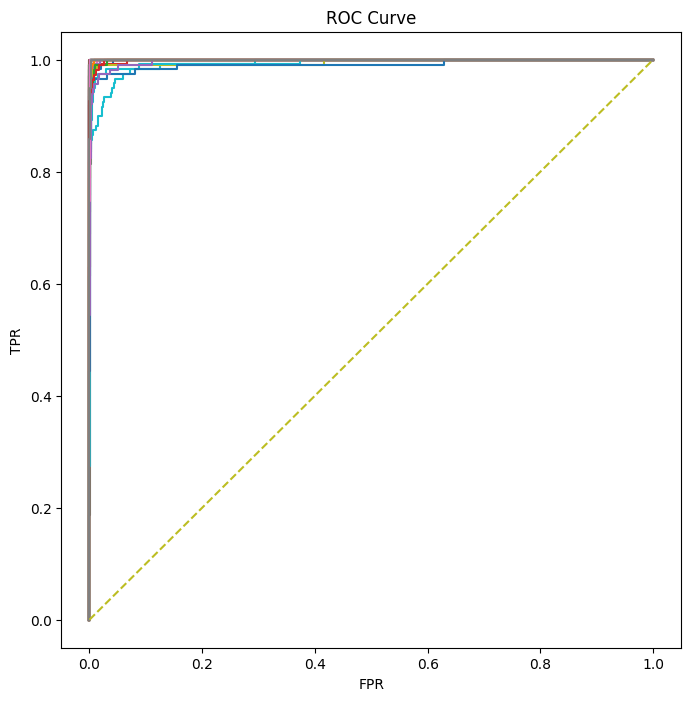

In [10]:
metrics_tf   = {}

for variant in VARIANTS:
    print("=" * 60)
    print(f"  TRANSFORMER FUSION — NOISED TEST  |  {variant}")
    print("=" * 60)

    noise_dir = os.path.join(NOISE_FEAT_PATH, variant)
    X_noise = np.load(os.path.join(noise_dir, "X_noise_test.npy"))
    y_noise = np.load(os.path.join(noise_dir, "y_noise_test.npy"))

    X_tf = scaler_tf.transform(X_noise)
    tf_loader = make_loader(X_tf, y_noise)

    tf_model.eval()
    all_true, all_pred, all_prob = [], [], []
    with torch.no_grad():
        for *feats, y in tf_loader:
            probs = torch.softmax(tf_model(*[f.to(DEVICE) for f in feats]), dim=1).cpu().numpy()
            all_true.append(y.numpy())
            all_pred.append(probs.argmax(axis=1))
            all_prob.append(probs)

    true_tf = np.concatenate(all_true)
    pred_tf = np.concatenate(all_pred)
    proba_tf = np.vstack(all_prob)

    metrics_tf[variant] = evaluate(true_tf, pred_tf, proba_tf)
    print()


In [11]:
import pandas as pd

rows = []
for variant in VARIANTS:
    rows.append({
        'Variant' : variant,
        'CatBoost_v1' : round(metrics_v1[variant]['Accuracy'], 4),
        'CatBoost_v2' : round(metrics_v2[variant]['Accuracy'], 4),
        'Transformer' : round(metrics_tf[variant]['Accuracy'],  4),
    })

df = pd.DataFrame(rows).set_index('Variant')

print(" \n NOISE ROBUSTNESS — ACCURACY SUMMARY\n")
display(df.style.format("{:.4f}"))

 
 NOISE ROBUSTNESS — ACCURACY SUMMARY



,CatBoost_v1,CatBoost_v2,Transformer
Variant,,,
salt_pepper_0.03,0.9400,0.9587,0.9776
salt_pepper_0.05,0.8858,0.9174,0.9486
salt_pepper_0.07,0.8226,0.8610,0.9002
gaussian,0.7628,0.7737,0.8502
masking,0.8671,0.8345,0.9420
